# LSTM实验
韩佳轩，23281106，计算机科学与技术学院

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# 导入数据集和工具函数
from datasets import TrafficDataset, my_Dataset
from utils import train, test, visualize, plot_metric

In [2]:
torch.manual_seed(23281106)  # 设置随机种子以确保结果可复现

## 手动实现LSTM

In [3]:
class MyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # 四个门共用一个线性层（i, f, o, g）
        self.gates = nn.Linear(input_size + hidden_size, hidden_size * 4)
        
        # 激活函数
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        
        # 输出层（可选，这里直接用最后一个隐藏状态预测）
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        # 参数初始化（Xavier）
        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)
    
    def forward(self, x):
        batch_size = x.size(0)
        seq_len = x.size(1)
        
        # 初始化隐藏状态和细胞状态
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        y_list = []
        
        for i in range(seq_len):
            # 拼接输入和上一时刻隐藏状态
            combined = torch.cat([x[:, i, :], h], dim=-1)
            
            # 计算四个门
            gates = self.gates(combined)
            input_gate, forget_gate, cell_gate, output_gate = gates.chunk(4, dim=-1)
            
            input_gate = self.sigmoid(input_gate)
            forget_gate = self.sigmoid(forget_gate)
            cell_gate = self.tanh(cell_gate)
            output_gate = self.sigmoid(output_gate)
            
            # 更新细胞状态和隐藏状态
            c = forget_gate * c + input_gate * cell_gate
            h = output_gate * self.tanh(c)
            
            # 输出（这里使用隐藏状态进行预测，可根据需要调整）
            y = self.output_layer(h)
            y_list.append(y)
        
        return torch.stack(y_list, dim=1), (h, c)

In [4]:
# 超参数设置
sensor = 171
window_size = 12
target = 'pm25'
batch_size = 64
hidden_size = 64
learning_rate = 0.001
num_epoch = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 数据加载,使用TrafficDataset
print("Loading dataset...")
dataset = TrafficDataset(sensor=96)
train_set, val_set, test_set = dataset.construct_set(
        train_por=0.6, test_por=0.2, window_size=window_size
    )
    
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)
    
input_size = train_set.X.shape[-1] 
print(f"Input size: {input_size}, Samples: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

Loading dataset...
Input size: 3, Samples: train=10701, val=3559, test=3560


d:\Programming&Labs\DeepLearning\Lab5\datasets.py:137: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  train_set = my_Dataset(torch.Tensor(train_x), torch.Tensor(train_y))


In [6]:
# 模型、损失、优化器
model = MyLSTM(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
# 反标准化函数（用于评估真实物理量）
def denormalize_fn(x):
    return dataset.denormalize(x.squeeze(-1))

In [7]:
# 训练
print("Start training MyLSTM...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None,          # 直接使用LSTM每一步的输出（最后一层已包含output_layer）
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

# 测试集最终评估
test_score, test_loss = test(
        net=model,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training MyLSTM...
*** epoch1, train loss 0.0038, train rmse 60.1929, val loss 0.0004, val rmse 22.306909, time use 3.216s
*** epoch2, train loss 0.0004, train rmse 22.9523, val loss 0.0004, val rmse 21.797320, time use 2.990s
*** epoch3, train loss 0.0004, train rmse 22.6240, val loss 0.0004, val rmse 21.824437, time use 3.049s
*** epoch4, train loss 0.0004, train rmse 22.3958, val loss 0.0004, val rmse 21.781972, time use 4.149s
*** epoch5, train loss 0.0004, train rmse 22.3173, val loss 0.0004, val rmse 20.998680, time use 3.007s
*** epoch6, train loss 0.0004, train rmse 22.1054, val loss 0.0004, val rmse 21.332066, time use 2.713s
*** epoch7, train loss 0.0004, train rmse 21.9365, val loss 0.0004, val rmse 20.714705, time use 3.061s
*** epoch8, train loss 0.0004, train rmse 22.0733, val loss 0.0004, val rmse 21.058932, time use 3.714s
*** epoch9, train loss 0.0004, train rmse 21.9640, val loss 0.0003, val rmse 20.568830, time use 3.079s
*** epoch10, train loss 0.0004, train r

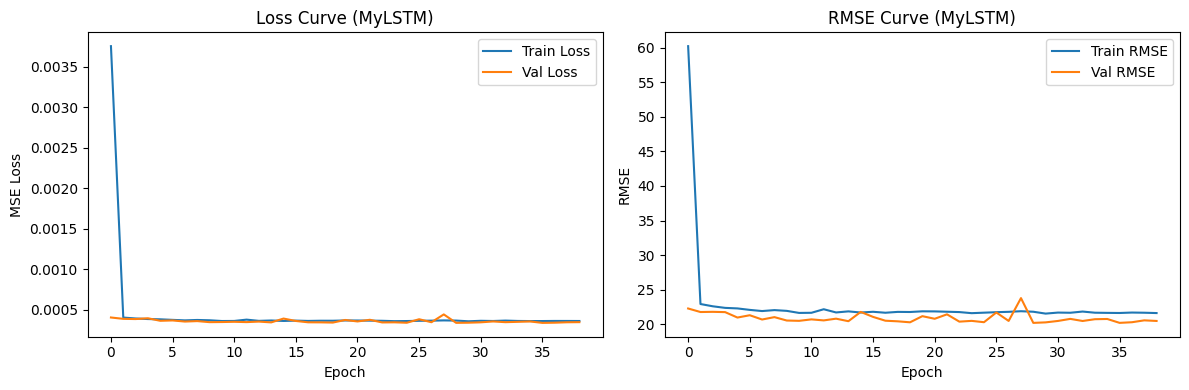

In [8]:
# 可视化
plt.figure(figsize=(12, 4))
    
plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (MyLSTM)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (MyLSTM)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('MyLSTM_training_curve.png')
plt.show()

## Torch.nn实现LSTM

In [9]:
class TorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.output(out), None  # 返回out和dummy hidden

In [10]:
# 模型、损失、优化器
model_Torch = TorchLSTM(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_Torch.parameters(), lr=learning_rate)

In [11]:
# 训练
print("Start training TorchLSTM...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model_Torch,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None,          # 直接使用LSTM每一步的输出（最后一层已包含output_layer）
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

# 测试集最终评估
test_score, test_loss = test(
        net=model_Torch,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training TorchLSTM...
*** epoch1, train loss 0.0034, train rmse 61.0455, val loss 0.0005, val rmse 23.907025, time use 0.831s
*** epoch2, train loss 0.0005, train rmse 24.3872, val loss 0.0005, val rmse 26.122563, time use 0.803s
*** epoch3, train loss 0.0004, train rmse 23.1935, val loss 0.0004, val rmse 22.062537, time use 0.824s
*** epoch4, train loss 0.0004, train rmse 23.0263, val loss 0.0005, val rmse 23.258455, time use 0.871s
*** epoch5, train loss 0.0004, train rmse 22.9473, val loss 0.0004, val rmse 21.410136, time use 0.760s
*** epoch6, train loss 0.0004, train rmse 22.5032, val loss 0.0005, val rmse 23.527997, time use 0.797s
*** epoch7, train loss 0.0004, train rmse 22.4104, val loss 0.0004, val rmse 21.972434, time use 0.736s
*** epoch8, train loss 0.0004, train rmse 22.2028, val loss 0.0005, val rmse 25.028655, time use 0.742s
*** epoch9, train loss 0.0004, train rmse 22.4961, val loss 0.0004, val rmse 21.570288, time use 0.707s
*** epoch10, train loss 0.0004, trai

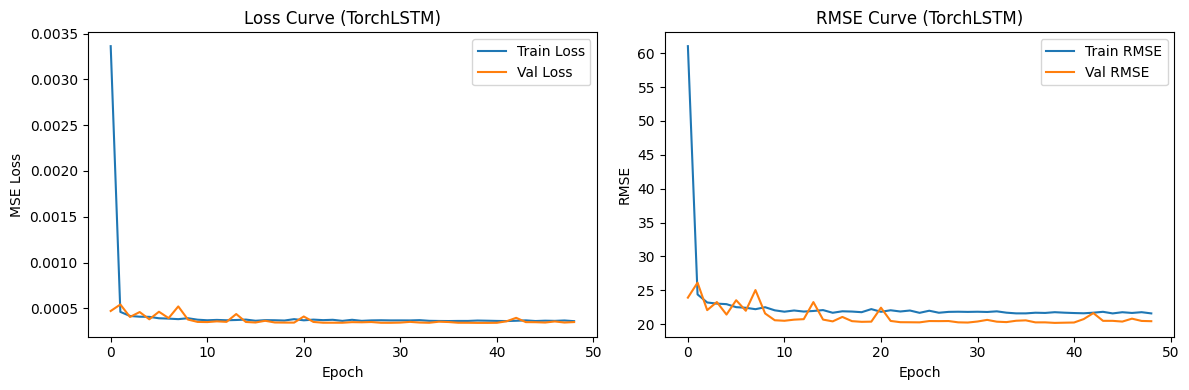

In [12]:
# 可视化
plt.figure(figsize=(12, 4))
    
plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (TorchLSTM)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (TorchLSTM)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('TorchLSTM_training_curve.png')
plt.show()